# Loading the Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#ml libraries
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, accuracy_score, davies_bouldin_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

In [2]:
#styling libraries
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

In [5]:
#load data
df = pd.read_csv('customer_segmentation_data.csv')

#basic data descriptions
print(f'Dataset shape: {df.shape}')
print(f'Top 5 rows: \n {df.head()}')
print(f'Data types: \n {df.dtypes}')

Dataset shape: (1000, 9)
Top 5 rows: 
    id  age  gender  income  spending_score  membership_years  \
0   1   38  Female   99342              90                 3   
1   2   21  Female   78852              60                 2   
2   3   60  Female  126573              30                 2   
3   4   40   Other   47099              74                 9   
4   5   65  Female  140621              21                 3   

   purchase_frequency preferred_category  last_purchase_amount  
0                  24          Groceries                113.53  
1                  42             Sports                 41.93  
2                  28           Clothing                424.36  
3                   5      Home & Garden                991.93  
4                  25        Electronics                347.08  
Data types: 
 id                        int64
age                       int64
gender                   object
income                    int64
spending_score            int64
membership_y

In [7]:
print(f'Overall Summary of Dataset: \n {df.describe()}')

Overall Summary of Dataset: 
                 id          age         income  spending_score  \
count  1000.000000  1000.000000    1000.000000     1000.000000   
mean    500.500000    43.783000   88500.800000       50.685000   
std     288.819436    15.042213   34230.771122       28.955175   
min       1.000000    18.000000   30004.000000        1.000000   
25%     250.750000    30.000000   57911.750000       26.000000   
50%     500.500000    45.000000   87845.500000       50.000000   
75%     750.250000    57.000000  116110.250000       76.000000   
max    1000.000000    69.000000  149973.000000      100.000000   

       membership_years  purchase_frequency  last_purchase_amount  
count        1000.00000         1000.000000           1000.000000  
mean            5.46900           26.596000            492.348670  
std             2.85573           14.243654            295.744253  
min             1.00000            1.000000             10.400000  
25%             3.00000           1

In [9]:
print(f'Number of missing values: \n{df.isnull().sum()}')

Number of missing values: 
id                      0
age                     0
gender                  0
income                  0
spending_score          0
membership_years        0
purchase_frequency      0
preferred_category      0
last_purchase_amount    0
dtype: int64


> The dataset contains a clean and robust set of demographic data for customer profiling.
- Total Records: 1000
- Null Values: **None**
- Feature Count: 8

### About Features:
- The customer base leans towards older people, with an average age of 43.7 years, but the dataset spans uniformly through ages 18 to 69.
- Customers do have high earnings, with an average of $88,500 annual income.
- On average, a customer retains their membership for over 5 years.
- Spending score is balanced overall, with most of the score under 76 out of 100, the remaining 25% are elite shoppers.
- Within a year, a customer made roughly 26 purchases, while the bottom 25% of users are making rare purchases ($\le$ 15 times), our top 25% are highly active shoppers, purchasing roughly 39 to 50 times.
- Customers do make big purchases frequently, with almost half of the customers spending nearly $500 on their last purchase.

# Exploratory Data Analysis

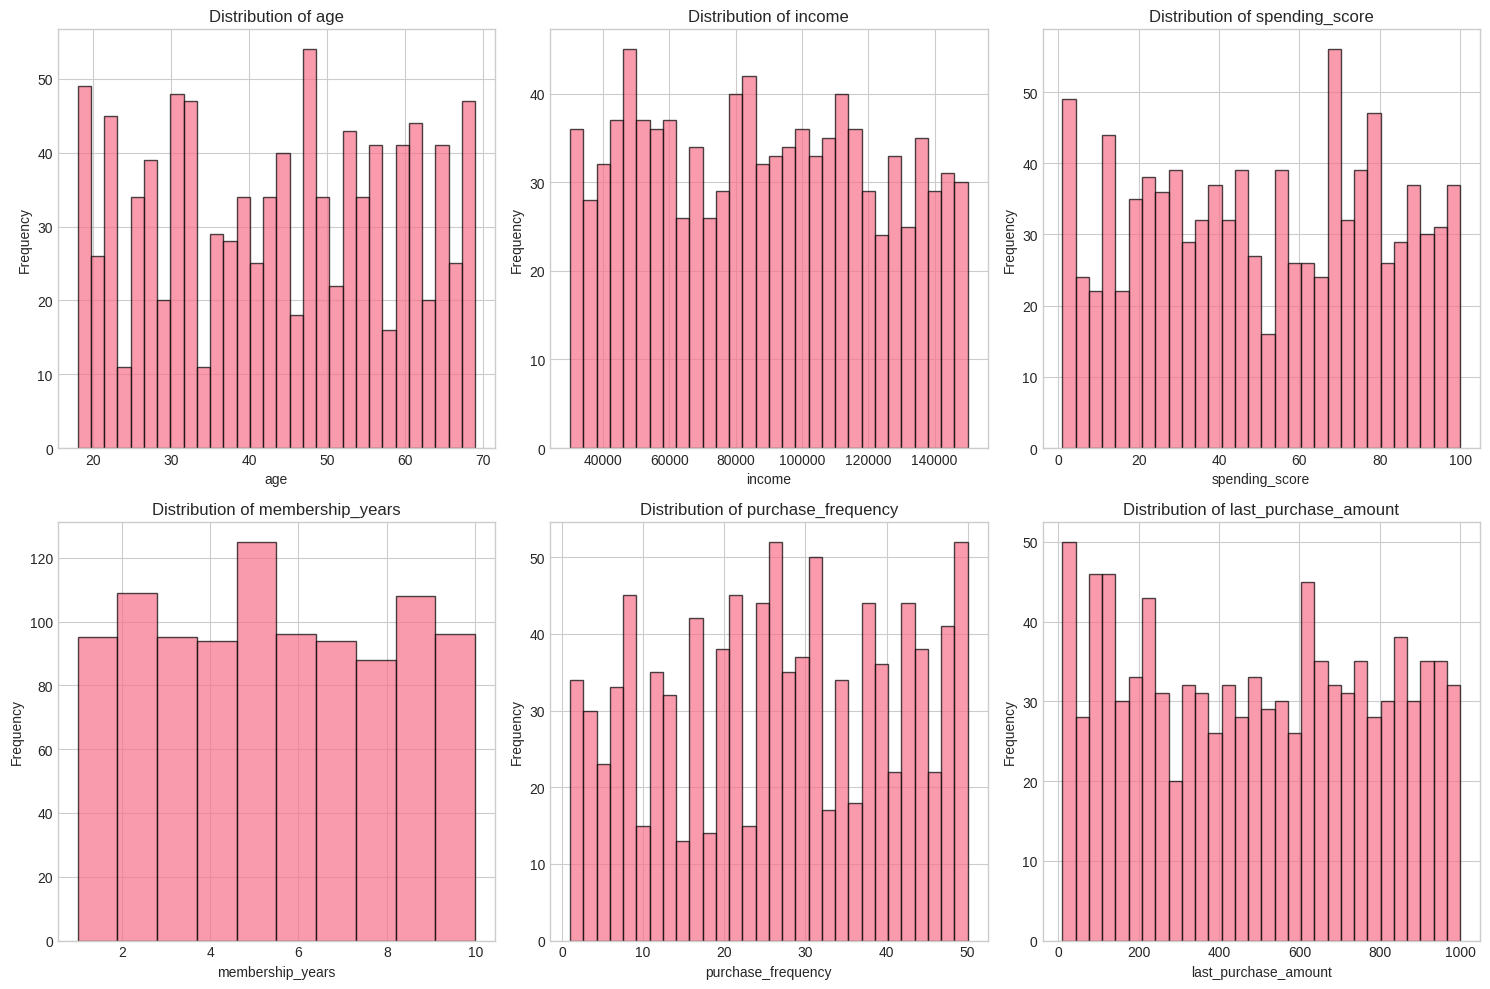

In [13]:
#distribution of features
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

num_features = ['age', 'income', 'spending_score', 'membership_years', 'purchase_frequency', 'last_purchase_amount']

for idx, feature in enumerate(num_features):
    row = idx // 3
    col = idx % 3
    if feature == "membership_years":
        axes[row,col].hist(df[feature], bins=10, edgecolor='black', alpha=0.7)
        axes[row,col].set_title(f'Distribution of {feature}')
        axes[row,col].set_xlabel(feature)
        axes[row,col].set_ylabel('Frequency')
    else:
        axes[row,col].hist(df[feature], bins=30, edgecolor='black', alpha=0.7)
        axes[row,col].set_title(f'Distribution of {feature}')
        axes[row,col].set_xlabel(feature)
        axes[row,col].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

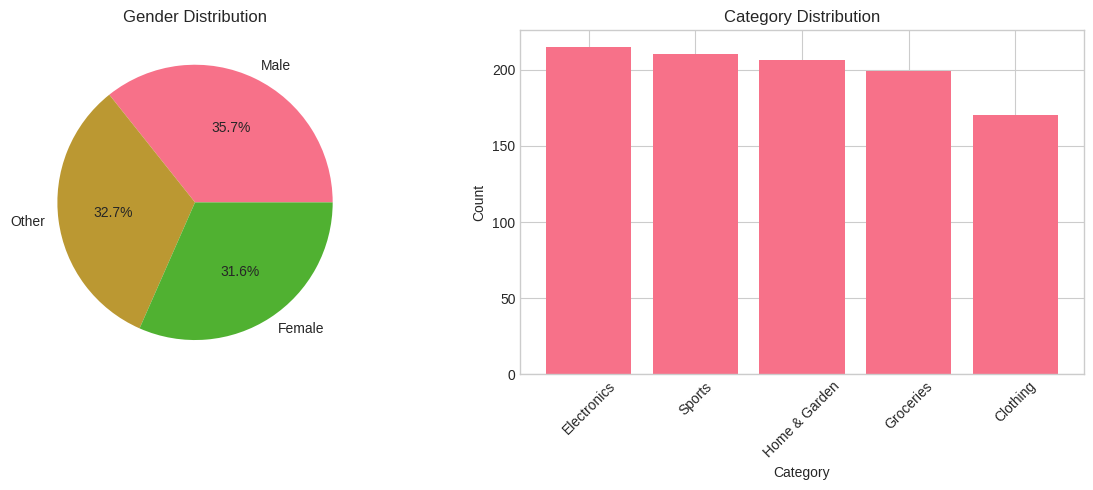

In [21]:
#distribution of gender of customer
fig, axes = plt.subplots(1,2, figsize=(12,5))

gender_counts = df['gender'].value_counts()
axes[0].pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%')
axes[0].set_title("Gender Distribution")

category_counts = df['preferred_category'].value_counts()
axes[1].bar(category_counts.index, category_counts.values)
axes[1].set_title("Category Distribution")
plt.xticks(rotation=45)
axes[1].set_xlabel("Category")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

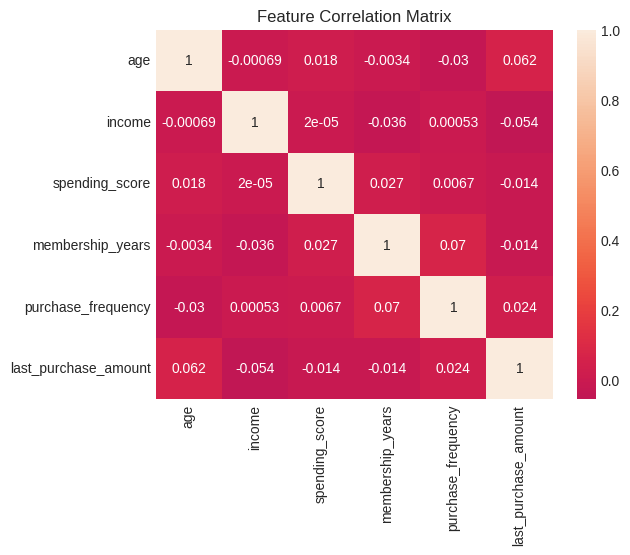

In [31]:
#correlation matrix of features
cm = df[num_features].corr()
sns.heatmap(cm, annot=True,cmap='rocket', center=0)
plt.title("Feature Correlation Matrix")

plt.show()

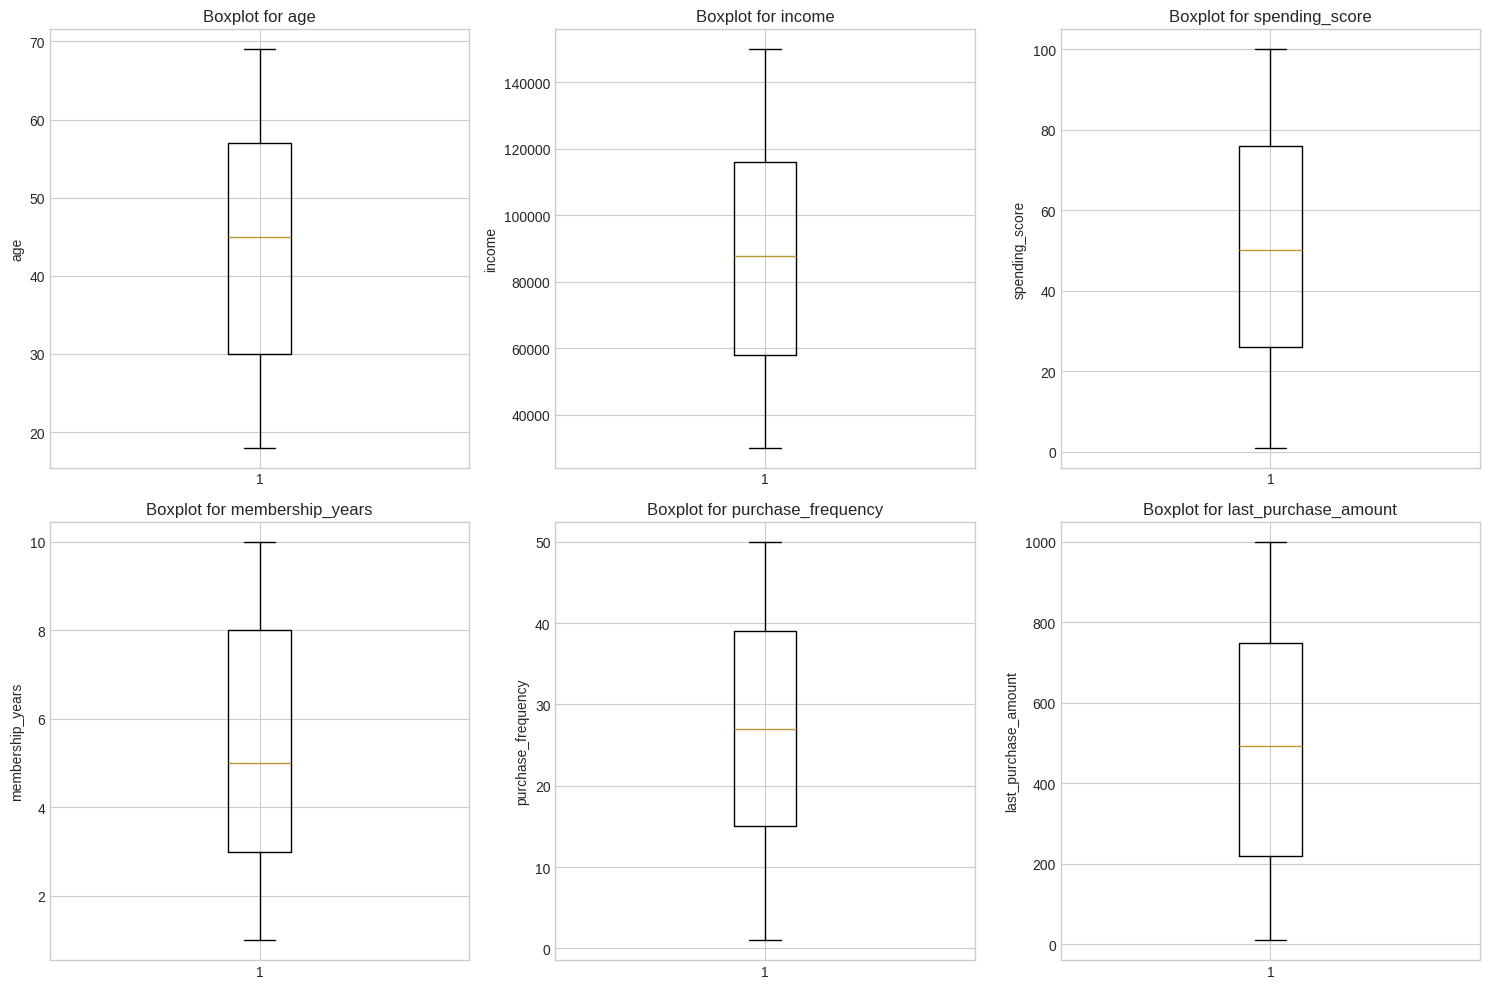

In [33]:
#checking outliers with boxplots

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for idx, feature in enumerate(num_features):
    row = idx // 3
    col = idx % 3
    axes[row,col].boxplot(df[feature])
    axes[row,col].set_title(f'Boxplot for {feature}')
    axes[row,col].set_ylabel(feature)
plt.tight_layout()
plt.show()

From the box plots, we can clearly see that:
- Customer base is more inclined towards older people
- Income is very balanced, with a large balanced range of total annual income
- Spending score is the most balanced feature in the dataset, with 50% people below 50/100 and 50% above
- Generally, people have a short membership span, with a few customers proving their loyalty above 5 years
- Customers do make around 2-3 purchases per year and spend on average ~ $500 per purchase, showing that customers do have purchasing power. This is also evident from the fact that the annual income is quite high!

# Feature Engineering

In [36]:
#creating new features to support further processing and clustering
df['spending_efficiency'] = df['spending_score'] / df['income'] * 10000
df['spending_efficiency'].head()

0     9.059612
1     7.609192
2     2.370174
3    15.711586
4     1.493376
Name: spending_efficiency, dtype: float64

In [38]:
df['loyalty_score'] = (df['purchase_frequency'] * df['membership_years']) / 100
df['loyalty_score'].head()

0    0.72
1    0.84
2    0.56
3    0.45
4    0.75
Name: loyalty_score, dtype: float64

In [76]:
# High number means they buy often but spend very little (Bargain Hunter)
# Low number means they buy rarely but drop huge amounts of money (Luxury Buyer)
df['bargain_hunter_index'] = df['purchase_frequency'] / (df['last_purchase_amount'] + 1)
df['bargain_hunter_index'].head()

0    0.209552
1    0.978337
2    0.065827
3    0.005036
4    0.071823
Name: bargain_hunter_index, dtype: float64

In [77]:
#projected customer lifetime value (CLV)
df['projected_ltv'] = (df['purchase_frequency'] / df['membership_years']) * df['last_purchase_amount']
df['projected_ltv'].head()

0     908.240000
1     880.530000
2    5941.040000
3     551.072222
4    2892.333333
Name: projected_ltv, dtype: float64

In [78]:
# at risk of churn
df['at_risk_churn'] = np.where((df['membership_years'] >= 5) & (df['purchase_frequency'] < 15), 1, 0)
df['at_risk_churn'].head()

0    0
1    0
2    0
3    1
4    0
Name: at_risk_churn, dtype: int64

In [79]:
#grouping by age
df['age_group'] = pd.cut(df['age'], bins=[0,25,35,50,100],
                        labels= ['Young', 'Young Adult', 'Middle Age', 'Senior'])
df['age_group'].head()

0    Middle Age
1         Young
2        Senior
3    Middle Age
4        Senior
Name: age_group, dtype: category
Categories (4, object): ['Young' < 'Young Adult' < 'Middle Age' < 'Senior']

In [80]:
#grouping by income
df['income_group'] = pd.cut(df['income'], bins=[0,50000,75000,100000,200000],
                        labels= ['Low', 'Medium', 'High', 'Very High'])
df['income_group'].head()

0         High
1         High
2    Very High
3          Low
4    Very High
Name: income_group, dtype: category
Categories (4, object): ['Low' < 'Medium' < 'High' < 'Very High']

In [81]:
numeric_features = ['age', 'income', 'spending_score', 'membership_years', 
                   'purchase_frequency', 'last_purchase_amount',
                   'spending_efficiency', 'engagement_score', 'loyalty_score', 'bargain_hunter_index', 'projected_ltv', 'at_risk_churn']

### Encoding variables

In [88]:
le_gender = LabelEncoder()
le_category = LabelEncoder()
le_age_group = LabelEncoder()
le_income_group = LabelEncoder()

df['gender_encoded'] = le_gender.fit_transform(df['gender'])    # 0, 1, 2 (Male, Female, Other)
df['category_encoded'] = le_category.fit_transform(df['preferred_category'])
df['age_group_encoded'] = le_age_group.fit_transform(df['age_group'])
df['income_group_encoded'] = le_income_group.fit_transform(df['income_group'])


#adding encoded categorical features to our feature list
features = numeric_features + ['gender_encoded', 'category_encoded', 'age_group_encoded', 'income_group_encoded']

In [89]:
X = df[features].copy()
#filling empty values, if any
X = X.fillna(X.median())


In [90]:
print("Total features: ")
for i, feature in enumerate(features):
    print(i, feature, sep='. ')

Total features: 
0. age
1. income
2. spending_score
3. membership_years
4. purchase_frequency
5. last_purchase_amount
6. spending_efficiency
7. engagement_score
8. loyalty_score
9. bargain_hunter_index
10. projected_ltv
11. at_risk_churn
12. gender_encoded
13. category_encoded
14. age_group_encoded
15. income_group_encoded


# Scaling features

In [96]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=features)
X_scaled_df.head()

,age,income,spending_score,membership_years,purchase_frequency,last_purchase_amount,spending_efficiency,engagement_score,loyalty_score,bargain_hunter_index,projected_ltv,at_risk_churn,gender_encoded,category_encoded,age_group_encoded,income_group_encoded
0,-0.384644,0.316868,1.358468,-0.865010,-0.182348,-1.281540,0.398679,-0.636223,-0.636223,0.219579,-0.534610,-0.405147,-1.260917,-0.051028,-1.168959,-1.507184
1,-1.515362,-0.282016,0.321865,-1.215358,1.082005,-1.523763,0.131270,-0.536134,-0.536134,2.705902,-0.539766,-0.405147,-1.260917,1.386386,0.692441,-1.507184
2,1.078639,1.112778,-0.714738,-1.215358,0.098620,-0.230005,-0.834628,-0.769675,-0.769675,-0.245243,0.401918,-0.405147,-1.260917,-1.488442,-0.238259,1.024480
3,-0.251618,-1.210096,0.805613,1.237080,-1.516943,1.690080,1.625078,-0.861423,-0.861423,-0.441847,-0.601073,2.468238,1.233479,0.667679,-1.168959,-0.663296
4,1.411203,1.523374,-1.025718,-0.865010,-0.112106,-0.491443,-0.996280,-0.611201,-0.611201,-0.225851,-0.165400,-0.405147,-1.260917,-0.769735,-0.238259,1.024480


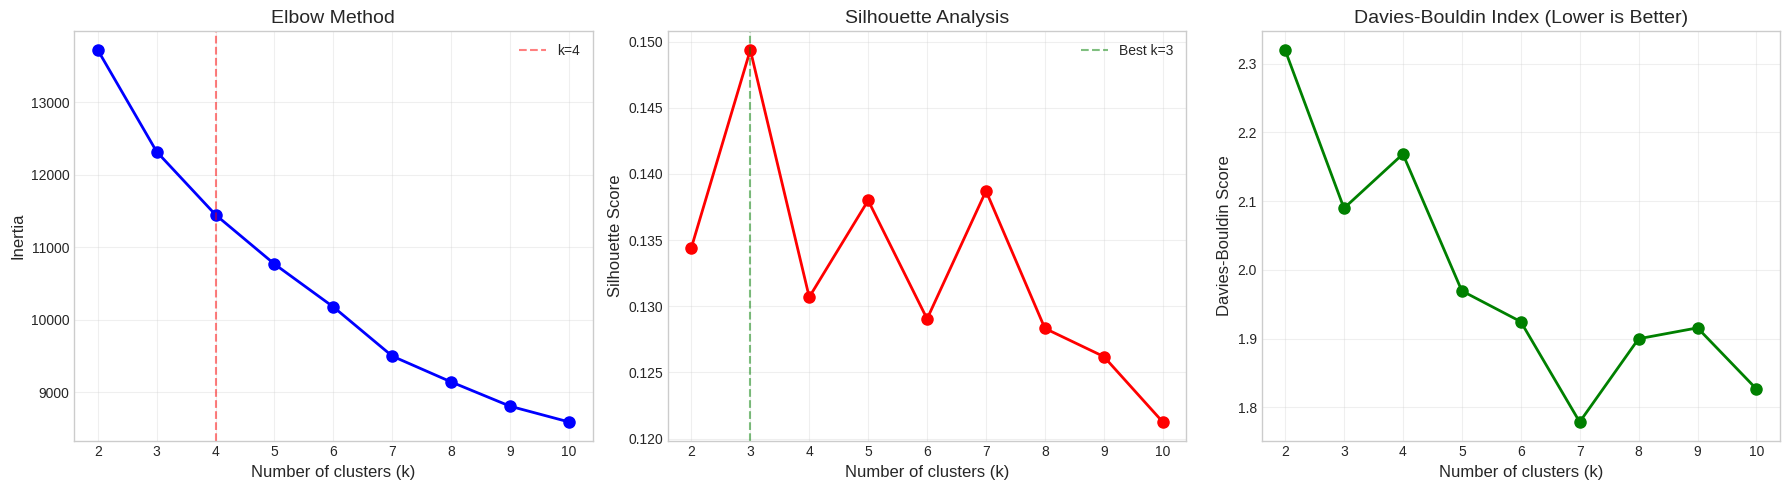


OPTIMAL K RECOMMENDATIONS
Based on Silhouette Score: k = 3 (score: 0.149)
Based on Davies-Bouldin Index: k = 7 (score: 1.779)

Common choices in customer segmentation: k=4 or k=5
Optimal K value found from algorithm: 3


In [97]:
def find_optimal_clusters(X, max_k=10):
    """Comprehensive method to find optimal k"""
    inertias = []
    silhouette_scores = []
    davies_bouldin_scores = []
    K = range(2, max_k + 1)
    
    for k in K:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
        labels = kmeans.fit_predict(X)
        
        inertias.append(kmeans.inertia_)
        silhouette_scores.append(silhouette_score(X, labels))
        davies_bouldin_scores.append(davies_bouldin_score(X, labels))
    
    # Plot results
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Elbow method
    axes[0].plot(K, inertias, 'bo-', linewidth=2, markersize=8)
    axes[0].set_xlabel('Number of clusters (k)', fontsize=12)
    axes[0].set_ylabel('Inertia', fontsize=12)
    axes[0].set_title('Elbow Method', fontsize=14)
    axes[0].grid(True, alpha=0.3)
    
    # Mark potential elbow points
    axes[0].axvline(x=4, color='red', linestyle='--', alpha=0.5, label='k=4')
    axes[0].legend()
    
    # Silhouette score
    axes[1].plot(K, silhouette_scores, 'ro-', linewidth=2, markersize=8)
    axes[1].set_xlabel('Number of clusters (k)', fontsize=12)
    axes[1].set_ylabel('Silhouette Score', fontsize=12)
    axes[1].set_title('Silhouette Analysis', fontsize=14)
    axes[1].grid(True, alpha=0.3)
    
    # Highlight best score
    best_k_sil = K[silhouette_scores.index(max(silhouette_scores))]
    axes[1].axvline(x=best_k_sil, color='green', linestyle='--', alpha=0.5, 
                    label=f'Best k={best_k_sil}')
    axes[1].legend()
    
    # Davies-Bouldin score (lower is better)
    axes[2].plot(K, davies_bouldin_scores, 'go-', linewidth=2, markersize=8)
    axes[2].set_xlabel('Number of clusters (k)', fontsize=12)
    axes[2].set_ylabel('Davies-Bouldin Score', fontsize=12)
    axes[2].set_title('Davies-Bouldin Index (Lower is Better)', fontsize=14)
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print recommendations
    best_k_silhouette = K[silhouette_scores.index(max(silhouette_scores))]
    best_k_db = K[davies_bouldin_scores.index(min(davies_bouldin_scores))]
    
    print("\n" + "="*50)
    print("OPTIMAL K RECOMMENDATIONS")
    print("="*50)
    print(f"Based on Silhouette Score: k = {best_k_silhouette} (score: {max(silhouette_scores):.3f})")
    print(f"Based on Davies-Bouldin Index: k = {best_k_db} (score: {min(davies_bouldin_scores):.3f})")
    print("\nCommon choices in customer segmentation: k=4 or k=5")
    
    return best_k_silhouette

# Find optimal k
optimal_k = find_optimal_clusters(X_scaled, max_k=10)

print(f'Optimal K value found from algorithm: {optimal_k}')


# Apply K-Means

In [104]:
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10, init='k-means++',max_iter=300, tol=0.0001)
df['cluster'] = kmeans.fit_predict(X_scaled)
print(f"K-Means clustering completed with {k} clusters")
print(f"Final inertia: {kmeans.inertia_:.2f}")
print(f"Number of iterations: {kmeans.n_iter_}")

K-Means clustering completed with 4 clusters
Final inertia: 11449.48
Number of iterations: 15


In [106]:
cluster_sizes = df['cluster'].value_counts().sort_index()
print("\nCluster Distribution:")
for cluster, size in cluster_sizes.items():
    print(f"Cluster {cluster}: {size} customers ({size/len(df)*100:.1f}%)")

# Detailed cluster analysis
cluster_analysis = df.groupby('cluster').agg({
    'age': ['mean', 'std'],
    'income': ['mean', 'std'],
    'spending_score': ['mean', 'std'],
    'membership_years': ['mean', 'std'],
    'purchase_frequency': ['mean', 'std'],
    'last_purchase_amount': ['mean', 'std'],
    'spending_efficiency': 'mean',
    'engagement_score': 'mean',
    'loyalty_score': 'mean',
    'bargain_hunter_index': 'mean',
    'projected_ltv': 'mean',
    'at_risk_churn': 'mean'
}).round(2)

print("\n" + "="*80)
print("DETAILED CLUSTER CHARACTERISTICS")
print("="*80)
display(cluster_analysis)



Cluster Distribution:
Cluster 0: 141 customers (14.1%)
Cluster 1: 296 customers (29.6%)
Cluster 2: 249 customers (24.9%)
Cluster 3: 314 customers (31.4%)

DETAILED CLUSTER CHARACTERISTICS


age            income           spending_score         \
          mean    std       mean       std           mean    std   
cluster                                                            
0        45.62  14.53   86265.85  34665.46          49.06  29.08   
1        42.25  14.90   85745.05  32120.02          50.20  30.16   
2        43.93  15.53  124056.63  15947.05          48.43  29.15   
3        44.29  14.95   63906.62  20162.72          53.66  27.44   

        membership_years       purchase_frequency        last_purchase_amount  \
                    mean   std               mean    std                 mean   
cluster                                                                         
0                   7.29  1.73               7.82   3.99               489.67   
1                   8.17  1.59              37.50   8.90               470.31   
2                   3.62  2.17              25.94  12.70               496.64   
3                   3.57  1.97              25.27  12.83               510.93   

                spending_efficiency engagement_score loyalty_score  \
            std                mean             mean          mean   
cluster                                                              
0        307.58                6.90            57.08          0.57   
1        298.26                6.70           301.72          3.02   
2        289.00                3.94            92.43          0.92   
3        293.26                9.42            88.88          0.89   

        bargain_hunter_index projected_ltv at_risk_churn  
                        mean          mean          mean  
cluster                                                   
0                       0.05        577.31           1.0  
1                       0.24       2270.88           0.0  
2                       0.11       5323.12           0.0  
3                       0.11       5420.82           0.0

#### Lets force the algo to learn complex patterns by dropping age and income entirely from the dataframe, to force the KMeans to find patterns among the other features.

In [117]:
X_behavior_only = df[['spending_score', 'purchase_frequency', 'last_purchase_amount', 'projected_ltv', 'loyalty_score', 'spending_efficiency']]
# Scale it
X_scaled_behavior = scaler.fit_transform(X_behavior_only)
# Run K-Means again with k=4 on THIS new dataset
final_kmeans = KMeans(n_clusters=k, random_state=42)
df['Behavior_Cluster'] = final_kmeans.fit_predict(X_scaled_behavior)

In [118]:
cluster_sizes = df['Behavior_Cluster'].value_counts().sort_index()
print("\nCluster Distribution:")
for cluster, size in cluster_sizes.items():
    print(f"Cluster {cluster}: {size} customers ({size/len(df)*100:.1f}%)")

# Detailed cluster analysis
cluster_analysis = df.groupby('cluster').agg({
    'age': ['mean', 'std'],
    'income': ['mean', 'std'],
    'spending_score': ['mean', 'std'],
    'membership_years': ['mean', 'std'],
    'purchase_frequency': ['mean', 'std'],
    'last_purchase_amount': ['mean', 'std'],
    'spending_efficiency': 'mean',
    'engagement_score': 'mean',
    'loyalty_score': 'mean',
    'bargain_hunter_index': 'mean',
    'projected_ltv': 'mean',
    'at_risk_churn': 'mean'
}).round(2)

print("\n" + "="*80)
print("DETAILED CLUSTER CHARACTERISTICS")
print("="*80)
display(cluster_analysis)


Cluster Distribution:
Cluster 0: 101 customers (10.1%)
Cluster 1: 325 customers (32.5%)
Cluster 2: 287 customers (28.7%)
Cluster 3: 287 customers (28.7%)

DETAILED CLUSTER CHARACTERISTICS


age            income           spending_score         \
          mean    std       mean       std           mean    std   
cluster                                                            
0        45.62  14.53   86265.85  34665.46          49.06  29.08   
1        42.25  14.90   85745.05  32120.02          50.20  30.16   
2        43.93  15.53  124056.63  15947.05          48.43  29.15   
3        44.29  14.95   63906.62  20162.72          53.66  27.44   

        membership_years       purchase_frequency        last_purchase_amount  \
                    mean   std               mean    std                 mean   
cluster                                                                         
0                   7.29  1.73               7.82   3.99               489.67   
1                   8.17  1.59              37.50   8.90               470.31   
2                   3.62  2.17              25.94  12.70               496.64   
3                   3.57  1.97              25.27  12.83               510.93   

                spending_efficiency engagement_score loyalty_score  \
            std                mean             mean          mean   
cluster                                                              
0        307.58                6.90            57.08          0.57   
1        298.26                6.70           301.72          3.02   
2        289.00                3.94            92.43          0.92   
3        293.26                9.42            88.88          0.89   

        bargain_hunter_index projected_ltv at_risk_churn  
                        mean          mean          mean  
cluster                                                   
0                       0.05        577.31           1.0  
1                       0.24       2270.88           0.0  
2                       0.11       5323.12           0.0  
3                       0.11       5420.82           0.0

Now we can see that KMeans has formed clusters based on spending score, purchase frequency and last purchase amount

# Applying PCA for visualization

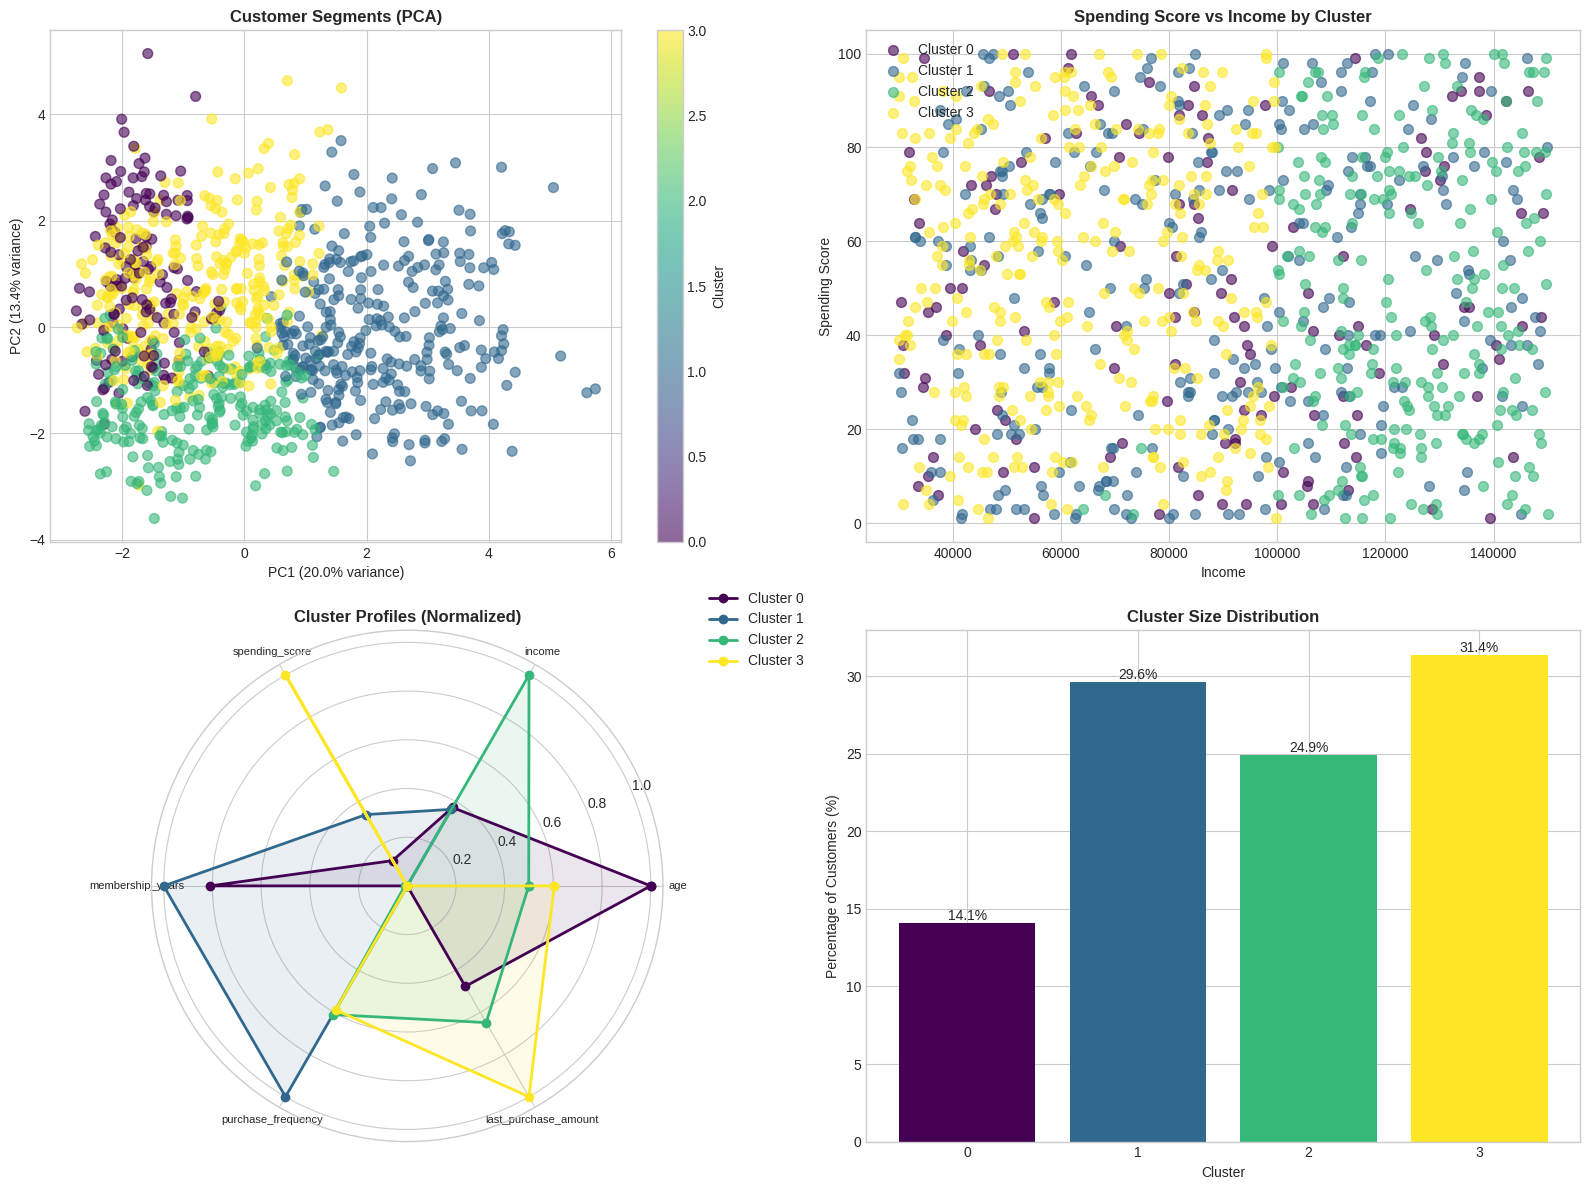

In [119]:
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

fig = plt.figure(figsize=(16, 12))

# Plot 1: PCA scatter plot
ax1 = fig.add_subplot(2, 2, 1)
scatter = ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=df['cluster'], 
                     cmap='viridis', alpha=0.6, s=50)
ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=10)
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=10)
ax1.set_title('Customer Segments (PCA)', fontsize=12, fontweight='bold')
plt.colorbar(scatter, ax=ax1, label='Cluster')

# Plot 2: Spending Score vs Income
ax2 = fig.add_subplot(2, 2, 2)
colors = plt.cm.viridis(np.linspace(0, 1, k))
for cluster in range(k):
    cluster_data = df[df['cluster'] == cluster]
    ax2.scatter(cluster_data['income'], cluster_data['spending_score'], 
               alpha=0.6, label=f'Cluster {cluster}', s=50, color=colors[cluster])
ax2.set_xlabel('Income', fontsize=10)
ax2.set_ylabel('Spending Score', fontsize=10)
ax2.set_title('Spending Score vs Income by Cluster', fontsize=12, fontweight='bold')
ax2.legend()

# Plot 3: Radar chart of cluster profiles
ax3 = fig.add_subplot(2, 2, 3, projection='polar')
radar_features = ['age', 'income', 'spending_score', 'membership_years', 
                  'purchase_frequency', 'last_purchase_amount']
cluster_means = df.groupby('cluster')[radar_features].mean()
# Normalize for radar chart
cluster_means_norm = (cluster_means - cluster_means.min()) / (cluster_means.max() - cluster_means.min())

angles = np.linspace(0, 2 * np.pi, len(radar_features), endpoint=False)
angles = np.concatenate((angles, [angles[0]]))  # Complete the circle

for cluster in range(k):
    values = cluster_means_norm.iloc[cluster].values
    values = np.concatenate((values, [values[0]]))
    ax3.plot(angles, values, 'o-', linewidth=2, label=f'Cluster {cluster}', color=colors[cluster])
    ax3.fill(angles, values, alpha=0.1, color=colors[cluster])
ax3.set_xticks(angles[:-1])
ax3.set_xticklabels(radar_features, fontsize=8)
ax3.set_title('Cluster Profiles (Normalized)', fontsize=12, fontweight='bold')
ax3.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

# Plot 4: Cluster sizes
ax4 = fig.add_subplot(2, 2, 4)
cluster_percentages = df['cluster'].value_counts(normalize=True).sort_index() * 100
bars = ax4.bar(range(k), cluster_percentages.values, color=colors)
ax4.set_xlabel('Cluster', fontsize=10)
ax4.set_ylabel('Percentage of Customers (%)', fontsize=10)
ax4.set_title('Cluster Size Distribution', fontsize=12, fontweight='bold')
ax4.set_xticks(range(k))

# Add percentage labels on bars
for bar, pct in zip(bars, cluster_percentages.values):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
            f'{pct:.1f}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [122]:
def generate_cluster_summary(df, k):
    profiles = {}

    for cluster in range(k):
        cluster_data = df[df['cluster'] == cluster]

        #metrics
        avg_age = cluster_data['age'].mean()
        avg_income = cluster_data['income'].mean()
        avg_spending = cluster_data['spending_score'].mean()
        avg_membership = cluster_data['membership_years'].mean()
        avg_freq = cluster_data['purchase_frequency'].mean()
        avg_amount = cluster_data['last_purchase_amount'].mean()

        #our own feature metrics
        avg_loyalty = cluster_data['loyalty_score'].mean() if 'loyalty_score' in df.columns else 0
        avg_ltv = cluster_data['projected_ltv'].mean() if 'projected_ltv' in df.columns else 0
        avg_bargain = cluster_data['bargain_hunter_index'].mean() if 'bargain_hunter_index' in df.columns else 0
        churn_risk_pct = (cluster_data['at_risk_churn'].mean() * 100) if 'at_risk_churn' in df.columns else 0

        # Calculate Global Averages to compare against
        global_ltv = df['projected_ltv'].mean() if 'projected_ltv' in df.columns else 1
        global_loyalty = df['loyalty_score'].mean() if 'loyalty_score' in df.columns else 1
        global_spending = df['spending_score'].mean()
        global_income = df['income'].mean()
        global_age = df['age'].mean()
        
        #gender
        gender_distribution = cluster_data['gender'].value_counts(normalize=True) * 100

        #categories
        category_distribution = cluster_data['preferred_category'].value_counts().head(3)

        if churn_risk_pct > 30: # Lowered the threshold slightly to catch early warnings
            profile_name = "High-Risk Churners"
            strategy = "Offer discounts, take active feedback, start aggressive campaigns"
            
        # If their LTV and Loyalty are 30% higher than the global average
        elif avg_ltv > (global_ltv * 1.3) and avg_loyalty > (global_loyalty * 1.3):
            profile_name = "VIPs"
            strategy = "Give early access to new products, no discounts for them"
            
        # Income is 20% higher than average, but spending is 20% lower
        elif avg_income > (global_income * 1.2) and avg_spending < (global_spending * 0.8):
            profile_name = "Untapped Wealth"
            strategy = "They have money but aren't spending it here. Push premium products."
            
        # Age is 15% younger than average, but spending is 20% higher
        elif avg_age < (global_age * 0.85) and avg_spending > (global_spending * 1.2):
            profile_name = "Trendy Advocates"
            strategy = "Social media targeted ads, referral codes, influencer-driven marketing."
            
        # Default bucket
        else:
            profile_name = "Core Mainstream"
            strategy = "Standard newsletter lifecycle, seasonal promotions, cross-selling."

        avg_age = cluster_data['age'].mean()
        avg_income = cluster_data['income'].mean()
        avg_spending = cluster_data['spending_score'].mean()
        avg_membership = cluster_data['membership_years'].mean()
        avg_freq = cluster_data['purchase_frequency'].mean()
        avg_amount = cluster_data['last_purchase_amount'].mean()


        profiles[cluster] = {
            'name': profile_name,
            'age': avg_age,
            'size': len(cluster_data),
            'frequency_purchase': avg_freq,
            'membership_years': avg_membership,
            'income':avg_income,
            'percentage': len(cluster_data) / len(df) * 100,
            'churn_risk': churn_risk_pct,
            'avg_ltv': avg_ltv,
            'avg_loyalty': avg_loyalty,
            'avg_income': avg_income,
            'dominant_gender': gender_distribution.idxmax() if not gender_distribution.empty else 'Mixed',
            'top_categories': category_distribution.head(3).to_dict(),
            'strategy': strategy
        }
    
    return profiles

profiles = generate_cluster_summary(df, k)


print("\n" + "="*80)
print("CUSTOMER SEGMENTATION - BUSINESS INSIGHTS")
print("="*80)
for cluster_id in sorted(profiles.keys()):
    p = profiles[cluster_id]
    
    # Strip any emojis you might have accidentally left in the profile names
    clean_name = p['name'].encode('ascii', 'ignore').decode('ascii').strip()
    
    print(f"\n{'-'*60}")
    print(f"CLUSTER {cluster_id}: {clean_name}")
    print(f"{'-'*60}")
    print(f"  Size: {p['size']} customers ({p['percentage']:.1f}% of base)")
    print(f"  Churn Risk: {p['churn_risk']:.1f}% of this group is at risk of leaving")
    print(f"  Projected LTV: ${p['avg_ltv']:,.2f}")
    print(f"  Loyalty Score: {p['avg_loyalty']:.1f}")
    
    print("\n  Demographics:")
    print(f"    - Average Age: {p['age']:.1f} years")
    print(f"    - Average Income: ${p['income']:,.0f}")
    print(f"    - Dominant Gender: {p['dominant_gender']}")
    
    print("\n  Behavior:")
    print(f"    - Membership: {p['membership_years']:.1f} years")
    print(f"    - Purchase Frequency: {p['frequency_purchase']:.1f}/year")
    
    print("\n  Top 3 Categories:")
    for cat, count in p['top_categories'].items():
        print(f"    - {cat}")
        
    print(f"\n  STRATEGY: {p['strategy']}")


CUSTOMER SEGMENTATION - BUSINESS INSIGHTS

------------------------------------------------------------
CLUSTER 0: High-Risk Churners
------------------------------------------------------------
  Size: 141 customers (14.1% of base)
  Churn Risk: 100.0% of this group is at risk of leaving
  Projected LTV: $577.31
  Loyalty Score: 0.6

  Demographics:
    - Average Age: 45.6 years
    - Average Income: $86,266
    - Dominant Gender: Other

  Behavior:
    - Membership: 7.3 years
    - Purchase Frequency: 7.8/year

  Top 3 Categories:
    - Clothing
    - Home & Garden
    - Electronics

  STRATEGY: Offer discounts, take active feedback, start aggressive campaigns

------------------------------------------------------------
CLUSTER 1: Core Mainstream
------------------------------------------------------------
  Size: 296 customers (29.6% of base)
  Churn Risk: 0.0% of this group is at risk of leaving
  Projected LTV: $2,270.88
  Loyalty Score: 3.0

  Demographics:
    - Average Age: 4

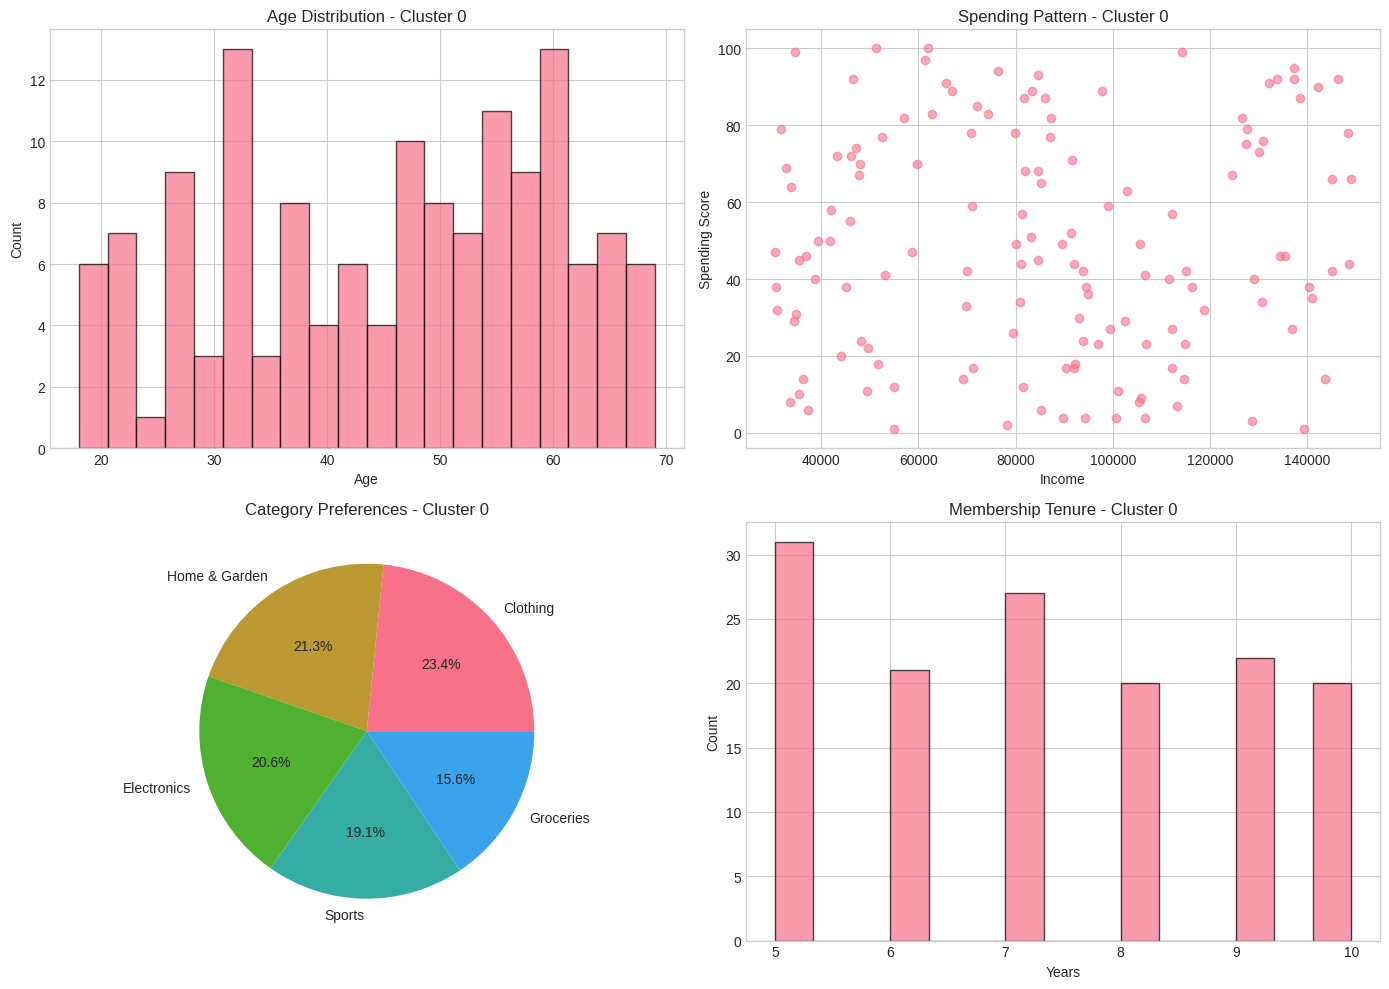


📋 RECOMMENDATIONS FOR CLUSTER 0:
  1. Target Age Range: 33 - 58 years
  2. Income Range: $54,918 - $112,260
  3. Focus Categories: Clothing, Home & Garden, Electronics
  4. Average Customer Lifetime Value: $69,043.04


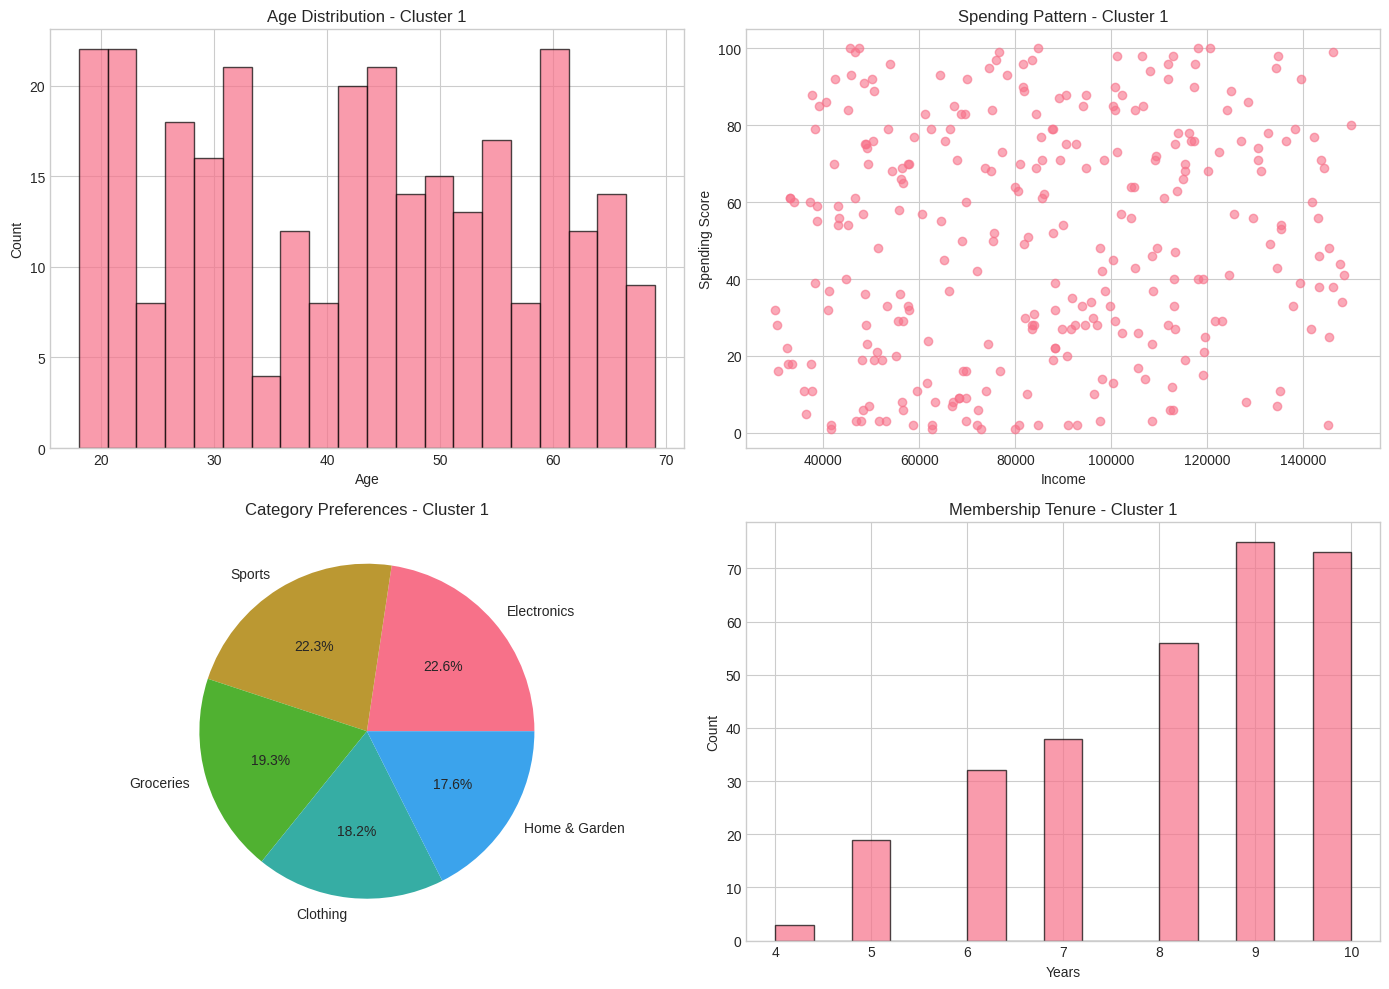


📋 RECOMMENDATIONS FOR CLUSTER 1:
  1. Target Age Range: 29 - 55 years
  2. Income Range: $56,673 - $111,762
  3. Focus Categories: Electronics, Sports, Groceries
  4. Average Customer Lifetime Value: $139,211.06


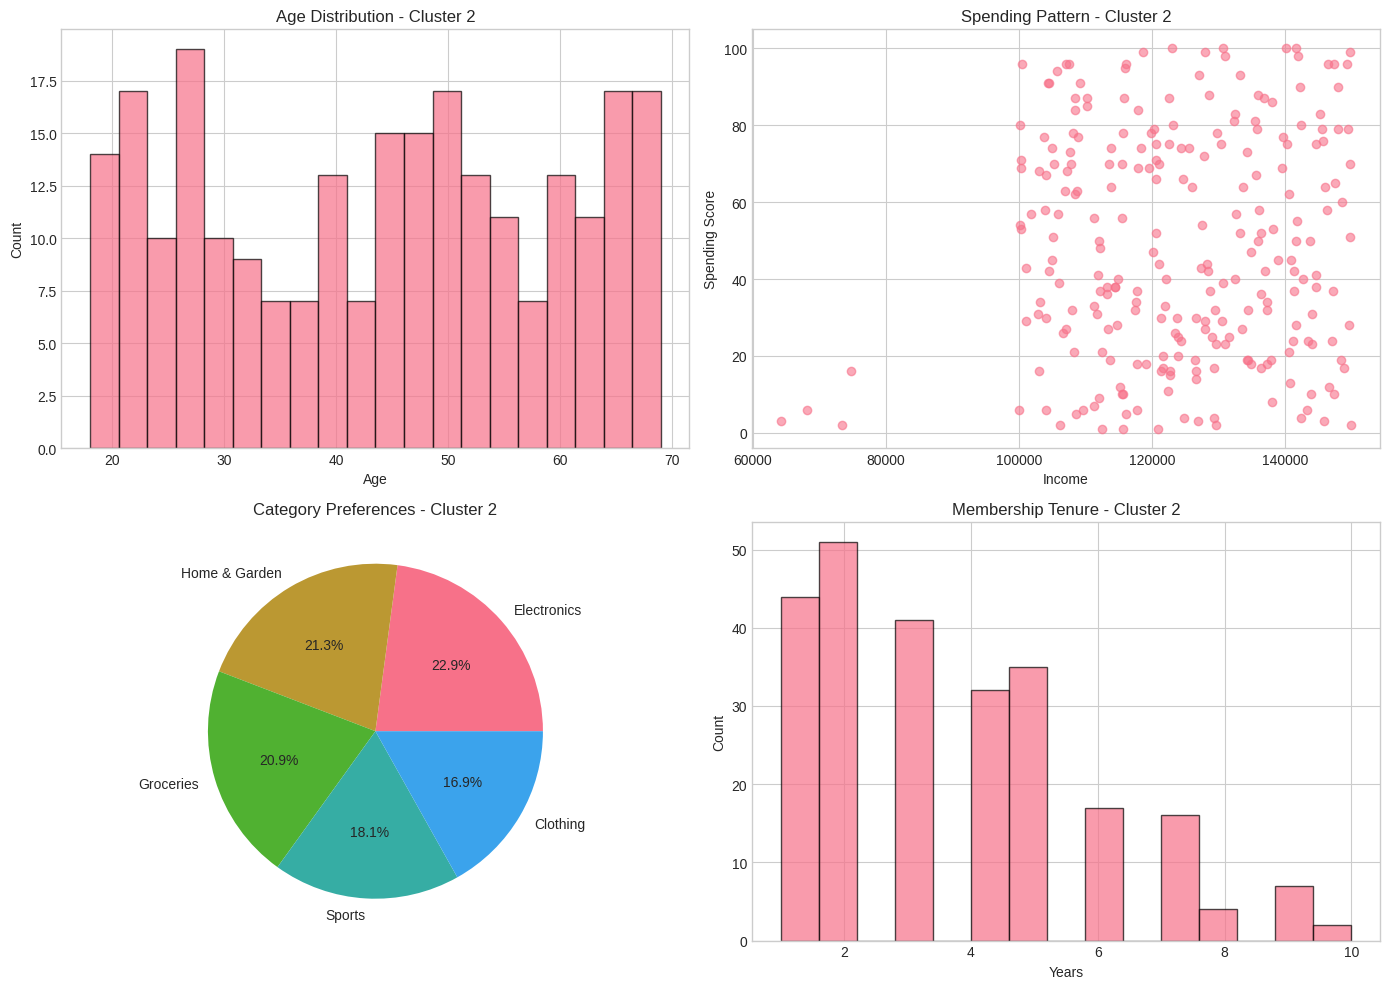


📋 RECOMMENDATIONS FOR CLUSTER 2:
  1. Target Age Range: 29 - 57 years
  2. Income Range: $112,137 - $136,928
  3. Focus Categories: Electronics, Home & Garden, Groceries
  4. Average Customer Lifetime Value: $123,663.39


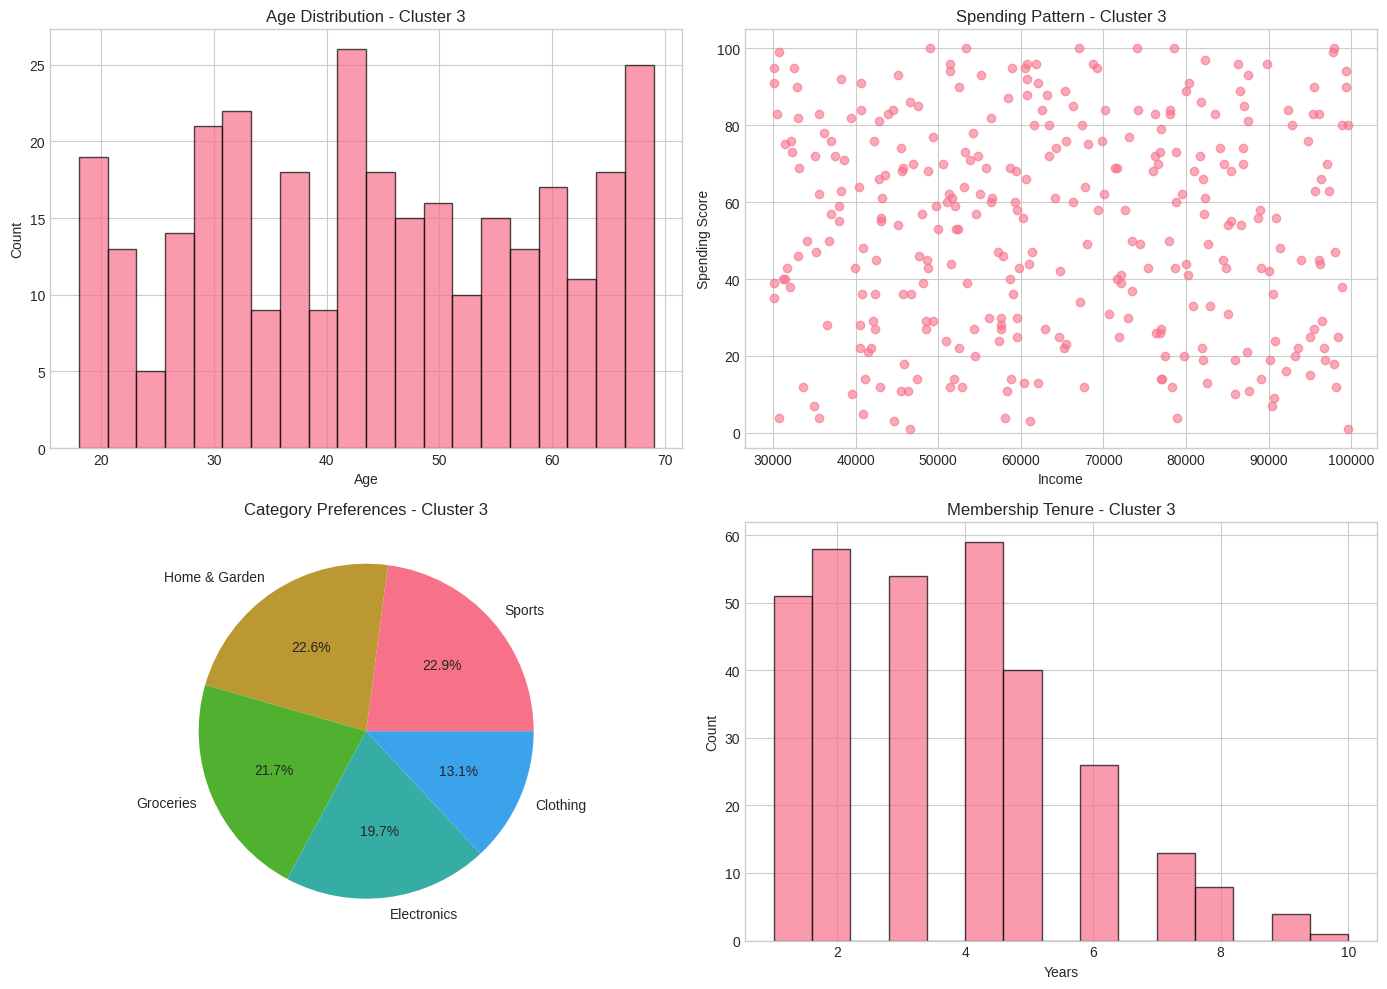


📋 RECOMMENDATIONS FOR CLUSTER 3:
  1. Target Age Range: 32 - 57 years
  2. Income Range: $46,778 - $81,564
  3. Focus Categories: Sports, Home & Garden, Groceries
  4. Average Customer Lifetime Value: $160,431.18


In [123]:
# Analyze specific clusters in detail
def analyze_customer_behavior(df, cluster_id):
    """Deep dive into a specific cluster"""
    cluster_data = df[df['cluster'] == cluster_id]
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Age distribution
    axes[0, 0].hist(cluster_data['age'], bins=20, edgecolor='black', alpha=0.7)
    axes[0, 0].set_title(f'Age Distribution - Cluster {cluster_id}')
    axes[0, 0].set_xlabel('Age')
    axes[0, 0].set_ylabel('Count')
    
    # Spending vs Income
    axes[0, 1].scatter(cluster_data['income'], cluster_data['spending_score'], alpha=0.6)
    axes[0, 1].set_xlabel('Income')
    axes[0, 1].set_ylabel('Spending Score')
    axes[0, 1].set_title(f'Spending Pattern - Cluster {cluster_id}')
    
    # Category preferences
    category_dist = cluster_data['preferred_category'].value_counts()
    axes[1, 0].pie(category_dist.values, labels=category_dist.index, autopct='%1.1f%%')
    axes[1, 0].set_title(f'Category Preferences - Cluster {cluster_id}')
    
    # Membership tenure
    axes[1, 1].hist(cluster_data['membership_years'], bins=15, edgecolor='black', alpha=0.7)
    axes[1, 1].set_title(f'Membership Tenure - Cluster {cluster_id}')
    axes[1, 1].set_xlabel('Years')
    axes[1, 1].set_ylabel('Count')
    
    plt.tight_layout()
    plt.show()
    
    # Print recommendations
    print(f"\n📋 RECOMMENDATIONS FOR CLUSTER {cluster_id}:")
    print(f"  1. Target Age Range: {cluster_data['age'].quantile(0.25):.0f} - {cluster_data['age'].quantile(0.75):.0f} years")
    print(f"  2. Income Range: ${cluster_data['income'].quantile(0.25):,.0f} - ${cluster_data['income'].quantile(0.75):,.0f}")
    print(f"  3. Focus Categories: {', '.join(category_dist.head(3).index)}")
    print(f"  4. Average Customer Lifetime Value: ${cluster_data['last_purchase_amount'].sum():,.2f}")

# Analyze each cluster
for cluster in range(k):
    analyze_customer_behavior(df, cluster)